# National Land Cover Database (NLCD) categories map (2023) 

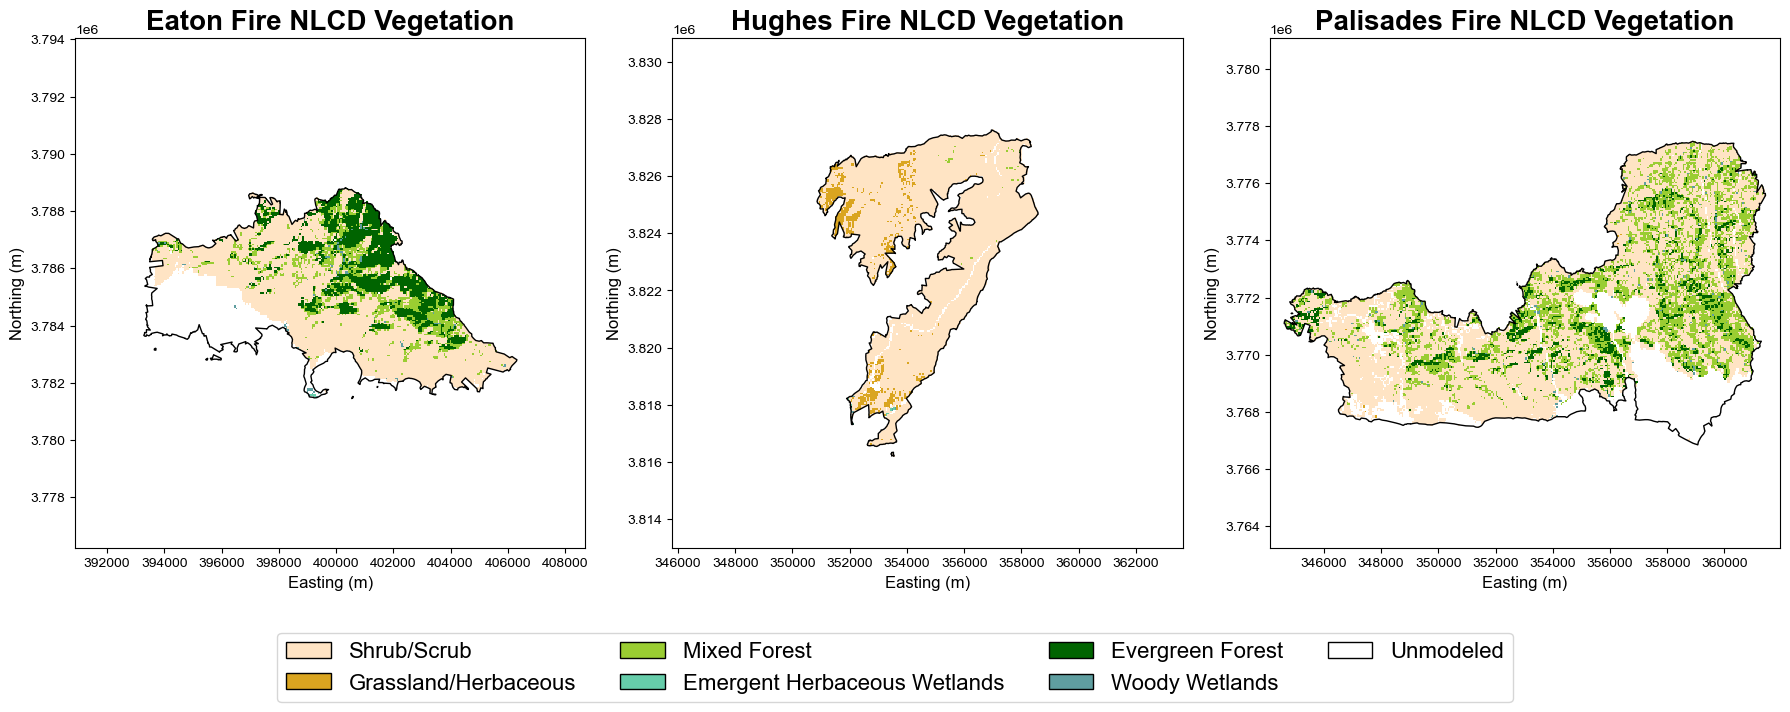

In [3]:
import numpy as np
import geopandas as gpd
import rasterio
import rasterio.mask
import rasterio.warp
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pyproj import CRS
import matplotlib as mpl

# Set default font family to Arial
mpl.rcParams["font.family"] = "Arial"


# -----------------------------
# Inputs
# -----------------------------
wildfire_rasters = {
    "Eaton": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Eaton_WFIGS_Interagency_Perimeters_YearToDate_-8396875942426194654/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/Eaton_LayerStack_updated20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/NLCD_Eaton_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/NLCD_Eaton_resampled.tif"
    },
    "Hughes": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Hughes_WFIGS_Interagency_Perimeters_YearToDate_7148479240675437113/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/Hughes_layerstack_updated_20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/NLCD_Hughes_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/NLCD_Hughes_resampled.tif"
    },
    "Palisades": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Palisades_WFIGS_Interagency_Perimeters_YearToDate_2024716492027912883/Perimeters_inward100m.shp",
        "stacked": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/Palisades_LayerStack_updated20250902",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/NLCD_Palisades_mask_resampled.tif",
        "nlcd_raster": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/NLCD_Palisades_resampled.tif"
    }
}

nlcd_classes = {
    11: 'Open Water', 12: 'Perennial Ice/Snow', 21: 'Developed, Open Space',
    22: 'Developed, Low Intensity', 23: 'Developed, Medium Intensity',
    24: 'Developed, High Intensity', 31: 'Barren Land', 41: 'Deciduous Forest',
    42: 'Evergreen Forest', 43: 'Mixed Forest', 52: 'Shrub/Scrub',
    71: 'Grassland/Herbaceous', 81: 'Pasture/Hay', 82: 'Cultivated Crops',
    90: 'Woody Wetlands', 95: 'Emergent Herbaceous Wetlands'
}

nlcd_palette = {
    "Shrub/Scrub": "bisque",
    "Grassland/Herbaceous": "goldenrod",
    "Mixed Forest": "yellowgreen",
    "Emergent Herbaceous Wetlands": "mediumaquamarine",
    "Evergreen Forest": "darkgreen",
    "Woody Wetlands": "cadetblue"
    

}

# -----------------------------
# Settings
# -----------------------------
# One common projected CRS for all panels (SoCal)
DST_CRS = CRS.from_epsg(32611)   # UTM Zone 11N (meters)
PAD_FRAC = 0.03                  # padding around perimeter bounds

# -----------------------------
# Helpers
# -----------------------------
def reproject_raster_to_crs(src, dst_crs: CRS):
    """Reproject an open rasterio dataset to dst_crs in memory (nearest)."""
    transform, width, height = rasterio.warp.calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    meta = src.meta.copy()
    meta.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    memfile = MemoryFile()
    dst = memfile.open(**meta)

    for i in range(1, src.count + 1):
        rasterio.warp.reproject(
            source=rasterio.band(src, i),
            destination=rasterio.band(dst, i),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    dst._memfile = memfile
    return dst

def read_perimeter_projected(perimeter_path: str, dst_crs: CRS) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(perimeter_path)
    if len(gdf) == 0:
        raise ValueError(f"No features found in perimeter: {perimeter_path}")
    if gdf.crs is None:
        raise ValueError(f"Perimeter shapefile has no CRS defined: {perimeter_path}")
    return gdf.to_crs(dst_crs)

def clip_raster_to_perimeter_projected(raster_path: str, perimeter_gdf_proj: gpd.GeoDataFrame, dst_crs: CRS):
    """Clip raster to perimeter, with both in dst_crs."""
    shapes = [geom for geom in perimeter_gdf_proj.geometry if geom is not None]
    if len(shapes) == 0:
        raise ValueError("No valid geometries in perimeter GeoDataFrame.")

    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster has no CRS defined: {raster_path}")

        if CRS.from_user_input(src.crs) != CRS.from_user_input(dst_crs):
            dst = reproject_raster_to_crs(src, dst_crs)
            working = dst
        else:
            working = src
            dst = None

        out_img, out_transform = rasterio.mask.mask(
            working, shapes, crop=True, nodata=working.nodata, filled=True
        )
        arr = out_img[0]

        if dst is not None:
            working.close()
            working._memfile.close()

    return arr, out_transform, dst_crs

def apply_optional_mask_projected(data_arr: np.ndarray, mask_raster_path: str, perimeter_gdf_proj: gpd.GeoDataFrame, dst_crs: CRS):
    """Apply mask raster (1=keep, 0=mask out), clipped/projected consistently."""
    if not mask_raster_path:
        return data_arr

    mask_arr, _, _ = clip_raster_to_perimeter_projected(mask_raster_path, perimeter_gdf_proj, dst_crs)

    r = min(data_arr.shape[0], mask_arr.shape[0])
    c = min(data_arr.shape[1], mask_arr.shape[1])
    data_arr = data_arr[:r, :c]
    mask_arr = mask_arr[:r, :c]

    out = data_arr.astype(np.int16, copy=True)  
    out[mask_arr != 1] = -9999
    return out

def build_palette_recode(nlcd_arr: np.ndarray):
    """Recode NLCD codes -> palette indices (0 other/white, 1..K palette), -9999 nodata."""
    class_order = list(nlcd_palette.keys())
    name_to_idx = {name: i+1 for i, name in enumerate(class_order)}  # 1..K

    out = np.zeros(nlcd_arr.shape, dtype=np.int16)
    out[nlcd_arr == -9999] = -9999

    for code, name in nlcd_classes.items():
        if name in name_to_idx:
            out[(nlcd_arr == code)] = name_to_idx[name]

    return out, class_order

def raster_extent_from_transform(transform, arr_shape):
    """Return extent (left, right, bottom, top) in map units for imshow."""
    left = transform.c
    top = transform.f
    xres = transform.a
    yres = transform.e  # often negative
    right = left + arr_shape[1] * xres
    bottom = top + arr_shape[0] * yres
    ymin, ymax = (bottom, top) if bottom < top else (top, bottom)
    xmin, xmax = (left, right) if left < right else (right, left)
    return (xmin, xmax, ymin, ymax)

# -----------------------------
# Colormap (0=white other, 1..K palette)
# -----------------------------
# Colormap (0=white other, 1..K palette)
class_order = list(nlcd_palette.keys())
colors = ["white"] + [nlcd_palette[c] for c in class_order]

cmap = ListedColormap(colors)
cmap.set_bad(color="white")

bounds = np.arange(-0.5, len(colors) + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)



# -----------------------------
# Precompute each fire + compute ONE common display span (meters)
# -----------------------------
fires = list(wildfire_rasters.keys())
fire_data = {}

spans = []  # collect max(width, height) for each fire in meters

for fire in fires:
    perim_path = wildfire_rasters[fire]["burn_perimeter"]
    nlcd_path = wildfire_rasters[fire]["nlcd_raster"]
    mask_path = wildfire_rasters[fire].get("mask", None)

    perim_gdf = read_perimeter_projected(perim_path, DST_CRS)
    minx, miny, maxx, maxy = perim_gdf.total_bounds

    width = maxx - minx
    height = maxy - miny
    span = max(width, height) * (1 + 2*PAD_FRAC)  # padded, square-ish window
    spans.append(span)

    # clip rasters in this CRS
    nlcd_clip, nlcd_transform, _ = clip_raster_to_perimeter_projected(nlcd_path, perim_gdf, DST_CRS)
    nlcd_clip = apply_optional_mask_projected(nlcd_clip, mask_path, perim_gdf, DST_CRS)

    recoded, class_order = build_palette_recode(nlcd_clip)
    recoded_ma = np.ma.masked_where(recoded == -9999, recoded)

    extent = raster_extent_from_transform(nlcd_transform, recoded.shape)

    # centroid for centered zoom window
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    fire_data[fire] = {
        "recoded_ma": recoded_ma,
        "extent": extent,
        "perim_gdf": perim_gdf,
        "centroid": (cx, cy),
        "bounds": (minx, miny, maxx, maxy)
    }

# ONE common span for all panels => same meters-per-inch scale across panels
COMMON_SPAN = max(spans)

# -----------------------------
# Plot panels (same scale; centered on each fire)
# -----------------------------
fig, axes = plt.subplots(1, len(fires), figsize=(18, 7))
if len(fires) == 1:
    axes = [axes]

for ax, fire in zip(axes, fires):
    d = fire_data[fire]

    ax.imshow(
        d["recoded_ma"],
        cmap=cmap,
        norm=norm,
        extent=d["extent"],
        interpolation="nearest"
    )

    d["perim_gdf"].boundary.plot(ax=ax, color="black", linewidth=1.0)

    cx, cy = d["centroid"]
    half = COMMON_SPAN / 2

    # same window size (meters) for every panel -> proportional comparison
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)

    ax.set_title(f"{fire} Fire NLCD Vegetation", fontsize=20, fontweight="bold")
    ax.set_xlabel("Easting (m)", fontsize=12)
    ax.set_ylabel("Northing (m)", fontsize=12)
    ax.set_aspect("equal")

# Legend — NLCD classes first, Unmodeled last
handles = [
    Patch(facecolor=color, edgecolor="black", label=label)
    for label, color in nlcd_palette.items()
]
handles += [Patch(facecolor="white", edgecolor="black", label="Unmodeled")]

fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=4,
    frameon=True,
    fontsize=16
)


plt.tight_layout(rect=(0, 0.12, 1, 1))
plt.savefig("/Users/megan/Desktop/NCLD_maps_final_updated20250203.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# EMIT Photosynthetic Vegetation Fractional Cover map (20250625)

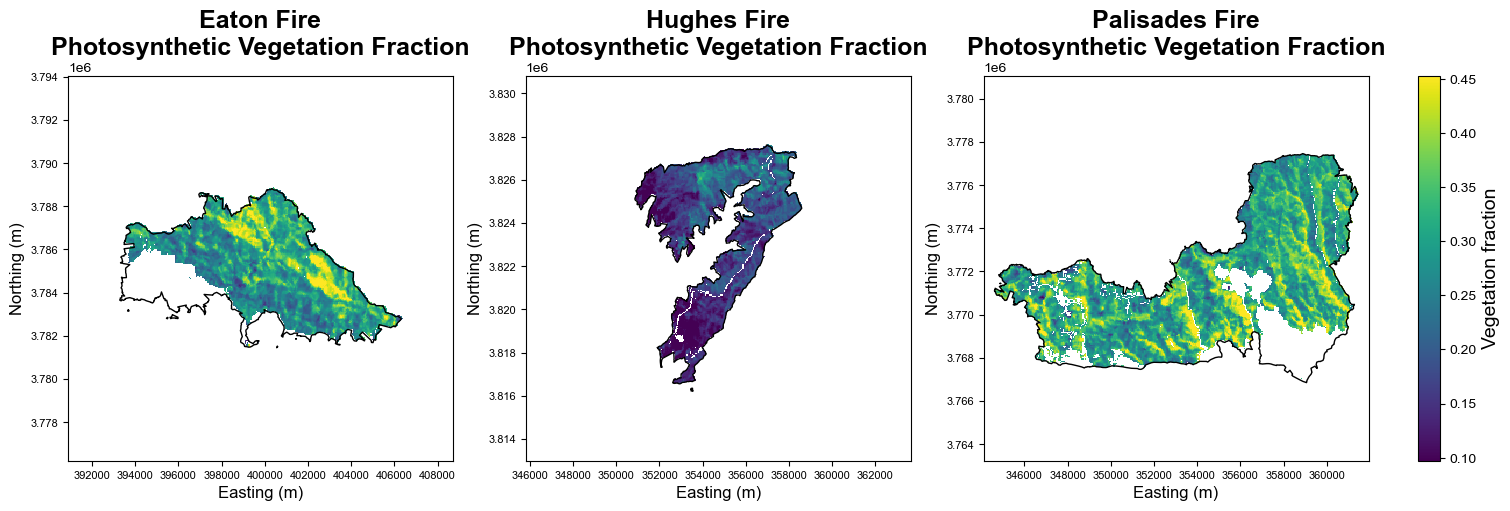

In [4]:
import numpy as np
import geopandas as gpd
import rasterio
import rasterio.mask
import rasterio.warp
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
from pyproj import CRS
import matplotlib as mpl
import matplotlib.gridspec as gridspec

mpl.rcParams["font.family"] = "Arial"

# -----------------------------
# Inputs
# -----------------------------
wildfire_rasters = {
    "Eaton": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Eaton_WFIGS_Interagency_Perimeters_YearToDate_-8396875942426194654/Perimeters_inward100m.shp",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/NLCD_Eaton_mask_resampled.tif",
    },
    "Hughes": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Hughes_WFIGS_Interagency_Perimeters_YearToDate_7148479240675437113/Perimeters_inward100m.shp",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/NLCD_Hughes_mask_resampled.tif",
    },
    "Palisades": {
        "burn_perimeter": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/data/allfires_model/burnperimeters/Palisades_WFIGS_Interagency_Perimeters_YearToDate_2024716492027912883/Perimeters_inward100m.shp",
        "mask": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/NLCD_Palisades_mask_resampled.tif",
    }
}

vegfrac_rasters = {
    "Eaton":     "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Eaton/Vfrac_EMIT_L2A_RFL_001_20240625T173907_2417712_009_SVD-band2.tif",
    "Hughes":    "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Hughes/Vfrac_EMIT_L2A_RFL_001_20240625T173907_2417712_009_SVD-band2.tif",
    "Palisades": "/Volumes/GEOG/EMIT_ECOSTRESS_wildfires/updated_allfiresmodel/Palisades/Vfrac_EMIT_L2A_RFL_001_20240625T173907_2417712_009_SVD-band2.tif"
}

# -----------------------------
# Settings
# -----------------------------
DST_CRS = CRS.from_epsg(32611)
PAD_FRAC = 0.03
USE_NLCD_MASK = True
FRACTION_IS_PERCENT_0_100 = False
VEG_NODATA_VALUE = -9999

# -----------------------------
# Helpers
# -----------------------------
def reproject_raster_to_crs(src, dst_crs: CRS, resampling: Resampling):
    """Reproject an open rasterio dataset to dst_crs in memory with chosen resampling."""
    transform, width, height = rasterio.warp.calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    meta = src.meta.copy()
    meta.update({"crs": dst_crs, "transform": transform, "width": width, "height": height})

    memfile = MemoryFile()
    dst = memfile.open(**meta)

    for i in range(1, src.count + 1):
        rasterio.warp.reproject(
            source=rasterio.band(src, i),
            destination=rasterio.band(dst, i),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=resampling
        )

    dst._memfile = memfile
    return dst

def read_perimeter_projected(perimeter_path: str, dst_crs: CRS) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(perimeter_path)
    if len(gdf) == 0:
        raise ValueError(f"No features found in perimeter: {perimeter_path}")
    if gdf.crs is None:
        raise ValueError(f"Perimeter shapefile has no CRS defined: {perimeter_path}")
    return gdf.to_crs(dst_crs)

def clip_raster_to_perimeter_projected(raster_path: str,
                                       perimeter_gdf_proj: gpd.GeoDataFrame,
                                       dst_crs: CRS,
                                       resampling: Resampling):
    """Clip raster to perimeter after reprojecting raster to dst_crs (if needed)."""
    shapes = [geom for geom in perimeter_gdf_proj.geometry if geom is not None]
    if len(shapes) == 0:
        raise ValueError("No valid geometries in perimeter GeoDataFrame.")

    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster has no CRS defined: {raster_path}")

        if CRS.from_user_input(src.crs) != CRS.from_user_input(dst_crs):
            dst = reproject_raster_to_crs(src, dst_crs, resampling=resampling)
            working = dst
        else:
            dst = None
            working = src

        out_img, out_transform = rasterio.mask.mask(
            working, shapes, crop=True, nodata=working.nodata, filled=True
        )
        arr = out_img[0]

        if dst is not None:
            working.close()
            working._memfile.close()

    return arr, out_transform

def reproject_mask_to_match_grid(mask_path: str, dst_crs: CRS, dst_transform, dst_shape):
    """
    Reproject mask onto an existing target grid (same transform/shape as veg clip).
    Uses nearest neighbor so 0/1 stays 0/1.
    """
    out = np.empty(dst_shape, dtype="float32")
    out[:] = np.nan

    with rasterio.open(mask_path) as src:
        if src.crs is None:
            raise ValueError(f"Mask raster has no CRS defined: {mask_path}")

        # If mask CRS differs, reproject directly into target grid
        rasterio.warp.reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    return out

def raster_extent_from_transform(transform, arr_shape):
    left = transform.c
    top = transform.f
    xres = transform.a
    yres = transform.e
    right = left + arr_shape[1] * xres
    bottom = top + arr_shape[0] * yres
    ymin, ymax = (bottom, top) if bottom < top else (top, bottom)
    xmin, xmax = (left, right) if left < right else (right, left)
    return (xmin, xmax, ymin, ymax)

# -----------------------------
# Precompute each fire + common span
# -----------------------------
fires = list(wildfire_rasters.keys())
fire_data = {}
spans = []

for fire in fires:
    perim_path = wildfire_rasters[fire]["burn_perimeter"]
    mask_path  = wildfire_rasters[fire].get("mask", None) if USE_NLCD_MASK else None
    veg_path   = vegfrac_rasters[fire]

    perim_gdf = read_perimeter_projected(perim_path, DST_CRS)
    minx, miny, maxx, maxy = perim_gdf.total_bounds

    width = maxx - minx
    height = maxy - miny
    span = max(width, height) * (1 + 2 * PAD_FRAC)
    spans.append(span)

    # Veg fraction: continuous -> bilinear
    veg_clip, veg_transform = clip_raster_to_perimeter_projected(
        veg_path, perim_gdf, DST_CRS, resampling=Resampling.bilinear
    )

    veg_clip = veg_clip.astype("float32")
    veg_clip[veg_clip == VEG_NODATA_VALUE] = np.nan

    if FRACTION_IS_PERCENT_0_100:
        veg_clip = veg_clip / 100.0

    # Mask: reproject to match veg grid -> nearest, then apply
    if mask_path:
        mask_on_veg_grid = reproject_mask_to_match_grid(
            mask_path,
            dst_crs=DST_CRS,
            dst_transform=veg_transform,
            dst_shape=veg_clip.shape
        )
        veg_clip[mask_on_veg_grid != 1] = np.nan

    extent = raster_extent_from_transform(veg_transform, veg_clip.shape)
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    fire_data[fire] = {
        "veg": veg_clip,
        "extent": extent,
        "perim_gdf": perim_gdf,
        "centroid": (cx, cy)
    }

COMMON_SPAN = max(spans)

# Consistent color scaling across fires (ignore NaNs)
all_vals = np.hstack([fire_data[f]["veg"].ravel() for f in fires])
vmin = np.nanpercentile(all_vals, 2)
vmax = np.nanpercentile(all_vals, 98)

# -----------------------------
# Plot panels with a dedicated colorbar axis
# -----------------------------
fig = plt.figure(figsize=(18, 5))  
gs = gridspec.GridSpec(
    nrows=1,
    ncols=len(fires) + 1,
    width_ratios=[1] * len(fires) + [0.05],
    wspace=0.08
)

axes = [fig.add_subplot(gs[0, i]) for i in range(len(fires))]
cax = fig.add_subplot(gs[0, -1])

for i, (ax, fire) in enumerate(zip(axes, fires)):
    d = fire_data[fire]

    im = ax.imshow(
        d["veg"],
        extent=d["extent"],
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis"
    )

    d["perim_gdf"].boundary.plot(ax=ax, color="black", linewidth=1.0)

    cx, cy = d["centroid"]
    half = COMMON_SPAN / 2
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect("equal")

    ax.set_title(f"{fire} Fire\nPhotosynthetic Vegetation Fraction", fontsize=18, fontweight="bold")
    ax.set_xlabel("Easting (m)", fontsize=12)
    ax.tick_params(axis="x", labelsize=8)

    # Show y-axis ticks/labels on ALL panels
    ax.set_ylabel("Northing (m)", fontsize=12)
    ax.tick_params(axis="y", labelsize=8)


cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Vegetation fraction", fontsize=14)

plt.savefig("/Users/megan/Desktop/Vfrac_maps_final.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()